In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

np.random.seed(1234)

stations = ["G", "L", "B", "Z"]

# Demand rates during peak periods [1000 passengers/h]
demand_peak = np.array(
    [
        [np.nan, 1.5, 2.2, 1.3],
        [np.nan, np.nan, 2.4, 1.1],
        [np.nan, np.nan, np.nan, 3.3],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Demand rates during off-peak periods [1000 passengers/h]
demand_offpeak = np.array(
    [
        [np.nan, 0.4, 0.3, 0.5],
        [np.nan, np.nan, 0.5, 0.3],
        [np.nan, np.nan, np.nan, 0.5],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during peak periods
first_class_ratio_peak = np.array(
    [
        [np.nan, 0.13, 0.15, 0.17],
        [np.nan, np.nan, 0.21, 0.18],
        [np.nan, np.nan, np.nan, 0.32],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during off-peak periods
first_class_ratio_offpeak = np.array(
    [
        [np.nan, 0.21, 0.18, 0.23],
        [np.nan, np.nan, 0.24, 0.23],
        [np.nan, np.nan, np.nan, 0.19],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

df_demand_peak = pd.DataFrame(demand_peak, index=stations, columns=stations)
df_demand_offpeak = pd.DataFrame(demand_offpeak, index=stations, columns=stations)
df_first_class_ratio_peak = pd.DataFrame(
    first_class_ratio_peak, index=stations, columns=stations
)
df_first_class_ratio_offpeak = pd.DataFrame(
    first_class_ratio_offpeak, index=stations, columns=stations
)

In [2]:
def exponential_rng(lam=1.0):
    """Generates exponential random number."""
    if lam <= 0:
        return float("inf")
    return -np.log(np.random.rand()) / lam


# Price constants
PRICE_FIRST = 40
PRICE_SECOND = 20
MISSED_COST_FIRST = 30
MISSED_COST_SECOND = 10
EMPTY_COST_FIRST = 20
EMPTY_COST_SECOND = 10


def get_travel_time(station):
    """Returns the travel time to the next station in minutes"""
    if station == "G":
        return 40
    if station == "L":
        return 70
    if station == "B":
        return 60
    return 0


def get_num_stations(origin, destination):
    """Calculates the number of stations between origin and destination for tickets"""
    return stations.index(destination) - stations.index(origin)


def is_peak(time_minutes):
    """Checks if we are in peak hours (7-9 or 16-18)"""
    time_of_day = time_minutes % (24 * 60)
    # 7:00 = 420, 9:00 = 540, 16:00 = 960, 18:00 = 1080
    if (420 <= time_of_day <= 540) or (960 <= time_of_day <= 1080):
        return True
    return False

In [3]:
class Passenger:
    def __init__(self, arrival_time, origin, destination, is_first_class):
        self.arrival_time = arrival_time
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class
        self.missed_trains = 0


max_number_of_carriages = 6


@dataclass
class TrainType:
    """Train can have a maximum number of six carriages"""

    name: str
    first_class_carriages: int
    second_class_carriages: int

    def __repr__(self):
        return f"{self.name}"

    def __post_init__(self):
        print(
            f"Creating TrainType: {self.name} with {self.first_class_carriages} first class and {self.second_class_carriages} second class carriages"
        )
        if (
            self.first_class_carriages + self.second_class_carriages
            > max_number_of_carriages
        ):
            raise ValueError(f"Total carriages cannot exceed {max_number_of_carriages}")
        if self.first_class_carriages < 0 or self.second_class_carriages < 0:
            raise ValueError("Carriage numbers cannot be negative")


@dataclass
class Train:
    train_id: int
    # Standard composition: 1 first class (300) and 3 second class (1500)
    train_type: TrainType

    # Lists to keep track of passengers on board
    onboard_first: list = None
    onboard_second: list = None

    def __post_init__(self):
        self.onboard_first = []
        self.onboard_second = []

    @property
    def capacity_first(self):
        return self.train_type.first_class_carriages * 300

    @property
    def capacity_second(self):
        return self.train_type.second_class_carriages * 500

In [4]:
@dataclass
class Event:
    """Generic event."""

    time: float


class PassengerGeneration(Event):
    """A passenger arrives at the station"""

    def __init__(self, time, origin, destination, is_first_class):
        super().__init__(time)
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class


@dataclass
class TrainArrival(Event):
    """The train arrives at a station"""

    station: str
    train: Train

In [5]:
def get_arrival_rate(
    origin, destination, is_first_class, time
):  # Calculates the arrival rate (lambda) in passengers per minute for a specific route and class
    peak = is_peak(time)

    # Choose the correct dataframe based on time
    if peak:
        demand_df = df_demand_peak
        ratio_df = df_first_class_ratio_peak
    else:
        demand_df = df_demand_offpeak
        ratio_df = df_first_class_ratio_offpeak

    total_demand_per_hour = demand_df.loc[origin, destination] * 1000

    # If NaN, the route does not exist
    if pd.isna(total_demand_per_hour):
        return 0

    first_class_ratio = ratio_df.loc[origin, destination]

    if is_first_class:
        rate_per_hour = total_demand_per_hour * first_class_ratio
    else:
        rate_per_hour = total_demand_per_hour * (1 - first_class_ratio)

    # Return the rate per minute
    return rate_per_hour / 60.0


def generate_timetable(
    freq_peak, freq_offpeak
):  # Generates all train arrival events for the day
    train_events = []
    t = 0
    train_id = 0

    while t < 24 * 60:
        train = Train(train_id)
        current_time = t

        # Make the train travel through the stations
        for station in stations:
            train_events.append(TrainArrival(current_time, station, train))
            current_time += get_travel_time(station)

        if is_peak(t):
            t += freq_peak
        else:
            t += freq_offpeak

        train_id += 1

    return train_events

In [6]:
base_train = TrainType(name="base", first_class_carriages=1, second_class_carriages=3)
short_train = TrainType(name="short", first_class_carriages=1, second_class_carriages=1)
long_train = TrainType(name="long", first_class_carriages=2, second_class_carriages=4)


def t_in_intervals(t, intervals: list[tuple[float]] | None):
    """Checks if time t is within any of the given intervals"""
    return any(start <= t <= end for start, end in intervals or [])


@dataclass
class Scenario:
    train_frequency_peak: float
    train_frequency_offpeak: float
    train_config_1: TrainType
    train_config_2: TrainType | None = None
    train_config_3: TrainType | None = None  # maximum 3 types
    train_type_2_intervals: list[tuple[float]] = None
    train_type_3_intervals: list[tuple[float]] = None
    peak_times: list[tuple[float]] = (
        (420, 540),
        (960, 1080),
    )  # Default peak times: 7-9 and 16-18

    def get_timetable(
        self,
        sorted_by_time: bool = True,
    ) -> list[TrainArrival]:
        train_events = []
        t = 0
        train_id = 0

        while t < 24 * 60:
            train_type = self.train_config_1
            if t_in_intervals(t, self.train_type_2_intervals):
                train_type = self.train_config_2
            elif t_in_intervals(t, self.train_type_3_intervals):
                train_type = self.train_config_3

            train = Train(
                train_id=train_id,
                train_type=train_type,
            )
            current_time = t

            # Make the train travel through the stations
            for station in stations:
                train_events.append(TrainArrival(current_time, station, train))
                current_time += get_travel_time(station)

            if t_in_intervals(t, self.peak_times):
                t += self.train_frequency_peak
            else:
                t += self.train_frequency_offpeak

            train_id += 1
        if sorted_by_time:
            train_events.sort(key=lambda event: event.time)
        return train_events

    def __str__(self):
        return f"Peak frequency: {self.train_frequency_peak} min, Off-peak frequency: {self.train_frequency_offpeak} min"


@dataclass
class SimulationResult:
    time_history: list[int]
    queue_history: list[int]
    waiting_times: list[float]
    total_revenue: float
    total_missed_cost: float
    total_empty_cost: float
    list_available_first: list[int]
    list_available_second: list[int]
    runtime_s: float

    def print_summary(self):
        minutes = int(self.runtime_s // 60)
        seconds = self.runtime_s % 60
        print(f"Runtime: {minutes} min {seconds:.2f} s")
        print(f"Passengers served: {len(self.waiting_times):,.2f}")
        print(f"Average waiting time: {np.mean(self.waiting_times):.2f} minutes")
        print(f"Total revenue: {self.total_revenue:,.2f} CHF")
        print(f"Missed passenger costs: {self.total_missed_cost:,.2f} CHF")
        print(f"Empty seat costs: {self.total_empty_cost:,.2f} CHF")
        profit = self.total_revenue - self.total_missed_cost - self.total_empty_cost
        print(f"NET PROFIT: {profit:,.2f} CHF\n")

    def __repr__(self):
        return "Result"


example_scenario = Scenario(
    train_frequency_peak=5.0,
    train_frequency_offpeak=10.0,
    train_config_1=base_train,
    train_config_2=short_train,
    train_config_3=long_train,
    train_type_2_intervals=[(0, 100), (250, 300)],  # Short trains during peak hours
    train_type_3_intervals=[(100, 600)],  # Long trains during off-peak hours
)

for event in example_scenario.get_timetable()[:5]:
    print(event)

Creating TrainType: base with 1 first class and 3 second class carriages
Creating TrainType: short with 1 first class and 1 second class carriages
Creating TrainType: long with 2 first class and 4 second class carriages
TrainArrival(time=0, station='G', train=Train(train_id=0, train_type=short, onboard_first=[], onboard_second=[]))
TrainArrival(time=10.0, station='G', train=Train(train_id=1, train_type=short, onboard_first=[], onboard_second=[]))
TrainArrival(time=20.0, station='G', train=Train(train_id=2, train_type=short, onboard_first=[], onboard_second=[]))
TrainArrival(time=30.0, station='G', train=Train(train_id=3, train_type=short, onboard_first=[], onboard_second=[]))
TrainArrival(time=40, station='L', train=Train(train_id=0, train_type=short, onboard_first=[], onboard_second=[]))


In [7]:
def simulate(scenario: Scenario) -> SimulationResult:
    start = time.time()
    # Initialize the queues at the stations
    queues = {}
    for s in stations:
        queues[s] = {"first": [], "second": []}

    events = scenario.get_timetable()

    # Generate the first passenger arrival event for each possible combination
    for origin in stations:
        for destination in stations:
            if stations.index(origin) >= stations.index(destination):
                continue

            for is_first in [True, False]:
                rate = get_arrival_rate(origin, destination, is_first, 0)
                if rate > 0:
                    time_first_arrival = exponential_rng(rate)
                    events.append(
                        PassengerGeneration(
                            time_first_arrival, origin, destination, is_first
                        )
                    )

    events.sort(key=lambda event: event.time)

    # State variables and statistics
    total_revenue = 0
    total_missed_cost = 0
    total_empty_cost = 0
    waiting_times = []

    # Lists to track queue over time for the plot
    time_history = []
    queue_history = []
    list_available_first = []
    list_available_second = []

    # Main loop
    while len(events) > 0:
        e = events.pop(0)

        if e.time > 24 * 60:
            break  # End of the day

        if isinstance(e, PassengerGeneration):
            # 1. Add the passenger to the platform queue
            p = Passenger(e.time, e.origin, e.destination, e.is_first_class)
            if p.is_first_class:
                queues[e.origin]["first"].append(p)
            else:
                queues[e.origin]["second"].append(p)

            # 2. Schedule the next generation
            rate = get_arrival_rate(e.origin, e.destination, e.is_first_class, e.time)
            next_time = e.time + exponential_rng(rate)
            events.append(
                PassengerGeneration(
                    next_time, e.origin, e.destination, e.is_first_class
                )
            )

        elif isinstance(e, TrainArrival):
            train = e.train
            station = e.station

            # 1. Passengers get off
            train.onboard_first = [
                p for p in train.onboard_first if p.destination != station
            ]
            train.onboard_second = [
                p for p in train.onboard_second if p.destination != station
            ]

            # 2. Passengers board
            if station != "Z":
                # First class boarding
                available_first = train.capacity_first - len(train.onboard_first)
                left_behind_first = []
                for p in queues[station]["first"]:
                    if available_first > 0:
                        train.onboard_first.append(p)
                        available_first -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_FIRST * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_FIRST
                    else:
                        p.missed_trains += 1
                        left_behind_first.append(p)
                queues[station]["first"] = left_behind_first
                total_empty_cost += available_first * EMPTY_COST_FIRST
                list_available_first.append(available_first)

                # Second class boarding
                available_second = train.capacity_second - len(train.onboard_second)
                left_behind_second = []
                for p in queues[station]["second"]:
                    if available_second > 0:
                        train.onboard_second.append(p)
                        available_second -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_SECOND * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_SECOND
                    else:
                        p.missed_trains += 1
                        left_behind_second.append(p)
                queues[station]["second"] = left_behind_second
                total_empty_cost += available_second * EMPTY_COST_SECOND
                list_available_second.append(available_second)

        # Calculate total passengers waiting right now
        current_total_queue = 0
        for s in stations:
            current_total_queue += len(queues[s]["first"]) + len(queues[s]["second"])

        time_history.append(e.time)
        queue_history.append(current_total_queue)

        events.sort(key=lambda event: event.time)
        end = time.time()
        runtime_s = end - start
    return SimulationResult(
        time_history=time_history,
        queue_history=queue_history,
        waiting_times=waiting_times,
        total_revenue=total_revenue,
        total_missed_cost=total_missed_cost,
        total_empty_cost=total_empty_cost,
        list_available_first=list_available_first,
        list_available_second=list_available_second,
        runtime_s=runtime_s,
    )

In [8]:
print("Starting simulation")

# Scenario 1: Constant frequency every 20 minutes

scenarios = {
    "base scenario 1": {
        "scenario": Scenario(
            train_frequency_peak=20,
            train_frequency_offpeak=20,
            train_config_1=base_train,
        )
    },
    "base scenario 2": {
        "scenario": Scenario(
            train_frequency_peak=15,
            train_frequency_offpeak=30,
            train_config_1=base_train,
        )
    },
    "many trains": {
        "scenario": Scenario(
            train_frequency_peak=5, train_frequency_offpeak=5, train_config_1=base_train
        )
    },
    "few trains": {
        "scenario": Scenario(
            train_frequency_peak=30,
            train_frequency_offpeak=30,
            train_config_1=base_train,
        )
    },
    "long trains": {
        "scenario": Scenario(
            train_frequency_peak=20,
            train_frequency_offpeak=20,
            train_config_1=long_train,
        )
    },
}


for scenario_name, scenario in scenarios.items():
    print(f"Simulating {scenario_name}...")
    result = simulate(scenario["scenario"])
    scenario["result"] = result
    print("\n" + "=" * 50)
    print(f"SCENARIO: {scenario_name}")
    print("=" * 50)
    result.print_summary()

Starting simulation
Simulating base scenario 1...

SCENARIO: base scenario 1
Runtime: 0 min 1.67 s
Passengers served: 96,597.00
Average waiting time: 15.47 minutes
Total revenue: 3,664,760.00 CHF
Missed passenger costs: 472,990.00 CHF
Empty seat costs: 2,595,570.00 CHF
NET PROFIT: 596,200.00 CHF

Simulating base scenario 2...

SCENARIO: base scenario 2
Runtime: 0 min 1.57 s
Passengers served: 96,426.00
Average waiting time: 16.76 minutes
Total revenue: 3,658,460.00 CHF
Missed passenger costs: 554,570.00 CHF
Empty seat costs: 1,679,680.00 CHF
NET PROFIT: 1,424,210.00 CHF

Simulating many trains...

SCENARIO: many trains
Runtime: 0 min 2.68 s
Passengers served: 97,043.00
Average waiting time: 3.08 minutes
Total revenue: 3,662,760.00 CHF
Missed passenger costs: 0.00 CHF
Empty seat costs: 15,744,780.00 CHF
NET PROFIT: -12,082,020.00 CHF

Simulating few trains...

SCENARIO: few trains
Runtime: 0 min 1.52 s
Passengers served: 96,133.00
Average waiting time: 40.44 minutes
Total revenue: 3,642

In [9]:
# Number of independent simulations
D = 1

print(f"Running {D} independent simulations for Scenario 1 (20-min frequency)...")
times_queues_scenario1 = []

for d in range(D):
    result = simulate(scenarios["base scenario 1"]["scenario"])
    times_queues_scenario1.append((result.time_history, result.queue_history))
    print(f"Simulation {d + 1}/{D} completed.")

times_queues_scenario2 = []

for d in range(D):
    result = simulate(scenarios["base scenario 2"]["scenario"])
    times_queues_scenario2.append((result.time_history, result.queue_history))
    print(f"Simulation {d + 1}/{D} completed.")

print("\nAll simulations done!")

Running 1 independent simulations for Scenario 1 (20-min frequency)...
Simulation 1/1 completed.
Simulation 1/1 completed.

All simulations done!


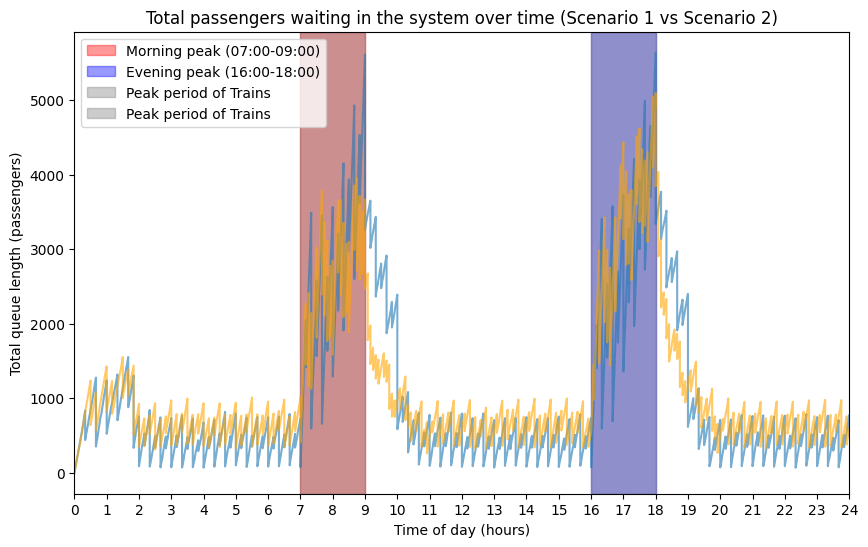

In [10]:
fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(1, 1, 1)

# Plot each simulation run
for t, q in times_queues_scenario1:
    # Convert time from minutes to hours
    t_hours = [time / 60 for time in t]
    ax.plot(t_hours, q, alpha=0.6)

for t, q in times_queues_scenario2:
    # Convert time from minutes to hours
    t_hours = [time / 60 for time in t]
    ax.plot(t_hours, q, alpha=0.6, color="orange")

# Formatting the plot
ax.set(
    title="Total passengers waiting in the system over time (Scenario 1 vs Scenario 2)",
    xlabel="Time of day (hours)",
    ylabel="Total queue length (passengers)",
)

# Add vertical lines to show the peak periods (now in hours!)
ax.axvspan(7, 9, color="red", alpha=0.4, label="Morning peak (07:00-09:00)")
ax.axvspan(16, 18, color="blue", alpha=0.4, label="Evening peak (16:00-18:00)")

scenario = scenarios["base scenario 1"]["scenario"]
for peak_start, peak_end in scenario.peak_times:
    peak_start_hours = peak_start / 60
    peak_end_hours = peak_end / 60
    ax.axvspan(
        peak_start_hours,
        peak_end_hours,
        color="gray",
        alpha=0.4,
        label="Peak period of Trains",
    )


# Set x-axis limits and ticks to show hours clearly (from 0 to 24, every 2 hours)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 1))

ax.legend()

plt.show()

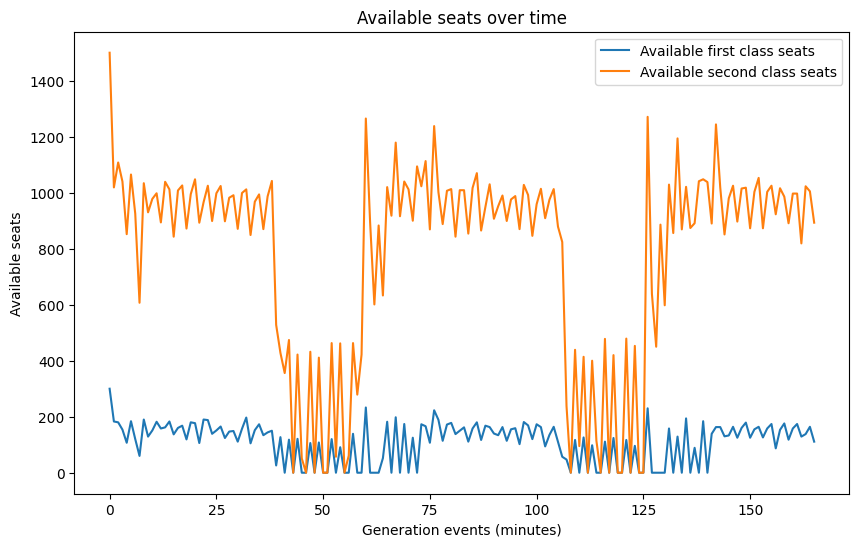

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(result.list_available_first, label="Available first class seats")
plt.plot(result.list_available_second, label="Available second class seats")
plt.xlabel("Generation events (minutes)")
plt.ylabel("Available seats")
plt.title("Available seats over time")
plt.legend()
plt.show()

## Statistical analysis

### Moving Mean and variance

Using Welford's

In [12]:
def moving_mean_var(new_data, old_mean, old_var, t):
    """Calculates moving sameple mean and variance at time t.

    Keywords:
        new_data (float): new data point arriving at time t.
        old_mean (float): previous sample mean.
        old_var (float): previous sample variance.
        t (int): time index

    Returns:
        new_mean (float): updated sample mean.
        new_var (float): updated sample variance.
    """
    if t == 1:
        new_mean = new_data
        new_var = 0
    else:
        new_mean = old_mean + (new_data - old_mean) / t
        new_var = (1 - 1 / (t - 1)) * old_var + t * (new_mean - old_mean) ** 2
    return new_mean, new_var

Next, run simulations

In [13]:
# Convergence criteria
PRECISION = 10.0  # Desired precision for the mean estimate (in passengers)
MIN_RUNS = 100
MAX_RUNS = 1000

# Initialize statistics tracking
max_queue_mean = 0
max_queue_var = 0
num_runs = 0

# Storage for visualization (convergence plots)
max_queue_all = []
max_queue_mean_all = []
max_queue_var_all = []

# Main simulation loop
print("Running queue simulations until convergence...")
while num_runs < MAX_RUNS:
    num_runs += 1

    # Run a single simulation replication
    result = simulate(scenarios["base scenario 1"]["scenario"])
    queues = result.queue_history
    max_queue = max(queues)

    # Update running statistics (Welford's algorithm)
    max_queue_mean, max_queue_var = moving_mean_var(
        max_queue, max_queue_mean, max_queue_var, num_runs
    )

    # Store for convergence visualization
    max_queue_all.append(max_queue)
    max_queue_mean_all.append(max_queue_mean)
    max_queue_var_all.append(max_queue_var)

    # Check convergence: standard error of mean < PRECISION
    # SE(mean) = sqrt(Var(X) / n)
    if num_runs >= MIN_RUNS:
        se_mean = np.sqrt(max_queue_var / num_runs)
        if se_mean < PRECISION:
            print(f"✓ Convergence reached after {num_runs} runs (SE = {se_mean:.4f})")
            break

    # Optional: print progress every 10 runs
    if num_runs % 10 == 0:
        se_mean = np.sqrt(max_queue_var / num_runs)
        print(f"  Run {num_runs:3d}: Mean = {max_queue_mean:.2f}, SE = {se_mean:.4f}")

Running queue simulations until convergence...
  Run  10: Mean = 5675.30, SE = 32.8045
  Run  20: Mean = 5676.05, SE = 20.2042
  Run  30: Mean = 5683.90, SE = 15.3331
  Run  40: Mean = 5698.35, SE = 16.3553
  Run  50: Mean = 5695.86, SE = 14.3767
  Run  60: Mean = 5701.67, SE = 13.0900
  Run  70: Mean = 5698.01, SE = 12.4857
  Run  80: Mean = 5694.53, SE = 11.6635
  Run  90: Mean = 5695.93, SE = 10.8819
  Run 100: Mean = 5691.94, SE = 10.3394
  Run 110: Mean = 5693.95, SE = 10.2721
✓ Convergence reached after 116 runs (SE = 9.9187)


Covergence diagnosis with a plot

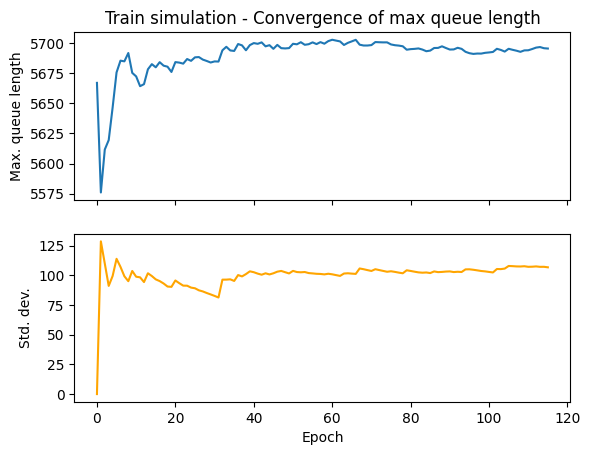

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(max_queue_mean_all, label="Mean")

ax2.plot(np.sqrt(max_queue_var_all), label="Std. dev.", color="orange")

ax1.set(
    title="Train simulation - Convergence of max queue length",
    ylabel="Max. queue length",
)
ax2.set(xlabel="Epoch", ylabel="Std. dev.")
plt.show()

## Bootstraping

In [15]:
### Bootstrap formula
def bootstrap_function(data, f_statistic, draws):
    """Calculates the bootstrap mse of a statistic of choice

    Keywords:
        data (array): data array.
        f_statistic: function handle calculating the statistic of interest.
        draws (int): number of bootstrap draws.

    Returns:
        mse (float): mean square error of the statistic of interest.
    """
    theta = f_statistic(data)
    emp_stats = np.zeros((draws,))
    se = np.zeros((draws,))
    for d in np.arange(draws):
        # this is a bootstrap sample
        data_draw = np.random.choice(data, size=data.shape[0], replace=True)
        # statistic is calculated using the bootstrap sample
        theta_emp = f_statistic(data_draw)
        emp_stats[d] = theta_emp
        # squared error is calculated between true value and estimate
        se[d] = (theta_emp - theta) ** 2
    return se.mean()

statistics functions

In [16]:
def q025(x):
    return np.quantile(x, 0.025)


def q975(x):
    return np.quantile(x, 0.975)


def worst(x):
    return np.max(x)


def mean_stat(x):
    return np.mean(x)


def var_stat(x):
    return np.var(x, ddof=1)

### Max queue

In [17]:
# resample 1000 times
BOOT_SIZE = 1000

# turn the queue data into a numpy array for easier processing
max_queue_all = np.array(max_queue_all)

# calculate bootstrap estimates for mean, variance, quantiles and worst case
boot_mean = bootstrap_function(max_queue_all, mean_stat, BOOT_SIZE)
boot_var = bootstrap_function(max_queue_all, var_stat, BOOT_SIZE)
boot_q025 = bootstrap_function(max_queue_all, q025, BOOT_SIZE)
boot_q975 = bootstrap_function(max_queue_all, q975, BOOT_SIZE)
boot_worst = bootstrap_function(max_queue_all, worst, BOOT_SIZE)

print("=" * 30, "BOOTSTRAP MSE ESTIMATES", "=" * 30)
print("Mean estimate:", f"{boot_mean:.5f}")
print("Variance estimate:", f"{boot_var:.5f}")
print("95% CI of max queue:", f"{boot_q025:.5f}", f"{boot_q975:.5f}")
print("Worst case estimate:", f"{boot_worst:.5f}")

============================== BOOTSTRAP MSE ESTIMATES ==============================
Mean estimate: 95.87507
Variance estimate: 2453499.57974
95% CI of max queue: 1116.75259 1165.73986
Worst case estimate: 1068.28600


[5667 5485 5683 5643 5755 5821 5744 5681 5747 5527 5643 5575 5686 5839
 5742 5641 5752 5632 5665 5593 5848 5675 5664 5775 5649 5761 5694 5630
 5653 5647 5712 5681 5993 5793 5591 5679 5906 5657 5539 5866 5767 5675
 5750 5556 5741 5559 5849 5568 5685 5709 5878 5678 5791 5585 5725 5785
 5619 5794 5623 5829 5770 5660 5659 5512 5814 5781 5787 5429 5651 5698
 5722 5880 5689 5693 5702 5569 5650 5673 5654 5469 5733 5713 5725 5618
 5577 5738 5881 5703 5814 5570 5580 5705 5820 5613 5462 5582 5635 5721
 5687 5755 5724 5734 5962 5599 5549 5940 5604 5613 5593 5823 5705 5811
 5828 5749 5585 5665]


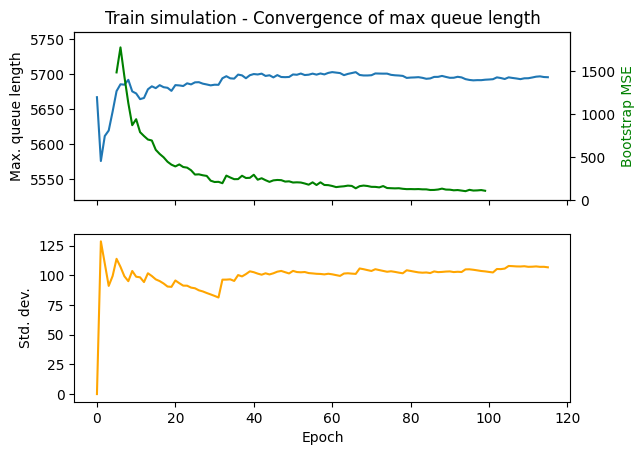

In [18]:
list_mse = []
print(max_queue_all)
xlin = list(range(5, 100))
for epoch in xlin:
    queue = max_queue_all[:epoch]
    boot_mean = bootstrap_function(queue, mean_stat, BOOT_SIZE)
    list_mse.append(boot_mean)


## same plot again
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(max_queue_mean_all, label="Mean")

ax2.plot(np.sqrt(max_queue_var_all), label="Std. dev.", color="orange")

ax1.set(
    title="Train simulation - Convergence of max queue length",
    ylabel="Max. queue length",
)
ax2.set(xlabel="Epoch", ylabel="Std. dev.")
ax1.set_ylim(min(max_queue_mean_all) * 0.99, max(max_queue_mean_all) * 1.01)

ax3 = ax1.twinx()
ax3.plot(xlin, list_mse, color="green", label="Bootstrap MSE")
ax3.set_ylim(0, max(list_mse) * 1.1)
ax3.set_ylabel("Bootstrap MSE", color="green")
plt.show()

In [19]:
def bootstrap_ci(boot_samples, alpha=0.05):
    lo = np.quantile(boot_samples, alpha / 2)
    hi = np.quantile(boot_samples, 1 - alpha / 2)
    return lo, hi


ci_mean = bootstrap_ci(boot_mean)

print("CI mean:", ci_mean)

CI mean: (np.float64(108.77682042648655), np.float64(108.77682042648655))


## Variance Reduction

### Anthetic draws

First change the simulation functions

In [20]:
# modifiy the exponential RNG for antithetic draws
def exponential_rng_anti(lam, u):
    """Generates exponential random number.
    u (float): Uniform random number.
    """
    # if lam <= 0:
    #    return float("inf")
    return -np.log(u) / lam


# Price constants
PRICE_FIRST = 40
PRICE_SECOND = 20
MISSED_COST_FIRST = 30
MISSED_COST_SECOND = 10
EMPTY_COST_FIRST = 20
EMPTY_COST_SECOND = 10

In [21]:
def simulate_anti(scenario: Scenario, u: np.ndarray) -> SimulationResult:
    start = time.time()
    # Initialize the queues at the stations
    queues = {}
    for s in stations:
        queues[s] = {"first": [], "second": []}

    events = scenario.get_timetable()

    i_arr = 0

    # Generate the first passenger arrival event for each possible combination
    for origin in stations:
        for destination in stations:
            if stations.index(origin) >= stations.index(destination):
                continue

            for is_first in [True, False]:
                rate = get_arrival_rate(origin, destination, is_first, 0)
                if rate > 0:
                    time_first_arrival = exponential_rng_anti(rate, u[i_arr])
                    events.append(
                        PassengerGeneration(
                            time_first_arrival, origin, destination, is_first
                        )
                    )
                    i_arr += 1

    events.sort(key=lambda event: event.time)

    # State variables and statistics
    total_revenue = 0
    total_missed_cost = 0
    total_empty_cost = 0
    waiting_times = []

    # Lists to track queue over time for the plot
    time_history = []
    queue_history = []
    list_available_first = []
    list_available_second = []

    # Main loop
    while len(events) > 0:
        e = events.pop(0)

        if e.time > 24 * 60:
            break  # End of the day

        if isinstance(e, PassengerGeneration):
            # 1. Add the passenger to the platform queue
            p = Passenger(e.time, e.origin, e.destination, e.is_first_class)
            if p.is_first_class:
                queues[e.origin]["first"].append(p)
            else:
                queues[e.origin]["second"].append(p)

            # 2. Schedule the next generation
            rate = get_arrival_rate(e.origin, e.destination, e.is_first_class, e.time)
            next_time = e.time + exponential_rng_anti(rate, u[i_arr])
            events.append(
                PassengerGeneration(
                    next_time, e.origin, e.destination, e.is_first_class
                )
            )
            i_arr += 1

        elif isinstance(e, TrainArrival):
            train = e.train
            station = e.station

            # 1. Passengers get off
            train.onboard_first = [
                p for p in train.onboard_first if p.destination != station
            ]
            train.onboard_second = [
                p for p in train.onboard_second if p.destination != station
            ]

            # 2. Passengers board
            if station != "Z":
                # First class boarding
                available_first = train.capacity_first - len(train.onboard_first)
                left_behind_first = []
                for p in queues[station]["first"]:
                    if available_first > 0:
                        train.onboard_first.append(p)
                        available_first -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_FIRST * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_FIRST
                    else:
                        p.missed_trains += 1
                        left_behind_first.append(p)
                queues[station]["first"] = left_behind_first
                total_empty_cost += available_first * EMPTY_COST_FIRST
                list_available_first.append(available_first)

                # Second class boarding
                available_second = train.capacity_second - len(train.onboard_second)
                left_behind_second = []
                for p in queues[station]["second"]:
                    if available_second > 0:
                        train.onboard_second.append(p)
                        available_second -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_SECOND * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_SECOND
                    else:
                        p.missed_trains += 1
                        left_behind_second.append(p)
                queues[station]["second"] = left_behind_second
                total_empty_cost += available_second * EMPTY_COST_SECOND
                list_available_second.append(available_second)

        # Calculate total passengers waiting right now
        current_total_queue = 0
        for s in stations:
            current_total_queue += len(queues[s]["first"]) + len(queues[s]["second"])

        time_history.append(e.time)
        queue_history.append(current_total_queue)

        events.sort(key=lambda event: event.time)
    end = time.time()
    runtime_s = end - start
    return SimulationResult(
        time_history=time_history,
        queue_history=queue_history,
        waiting_times=waiting_times,
        total_revenue=total_revenue,
        total_missed_cost=total_missed_cost,
        total_empty_cost=total_empty_cost,
        list_available_first=list_available_first,
        list_available_second=list_available_second,
        runtime_s=runtime_s,
    )

In [22]:
# Convergence parameters
PRECISION = 10  # Target standard error for convergence
MIN_RUNS = 100  # Minimum runs before checking convergence
MAX_RUNS = 1000  # Safety limit to prevent infinite loops
RNG_SIZE = 100000  # Size of random number array

# Train frequency scenarios
TRAIN_FREQUENCY_PEAK = 20
TRAIN_FREQUENCY_OFFPEAK = 20

# Initialize statistics tracking
max_queue_mean = 0.0
max_queue_var = 0.0
num_runs_ind = 0

# Storage for downstream analysis
max_queue_all = []
max_queue_mean_all = []
max_queue_var_all = []

# Main simulation loop with convergence checking
print("Running queue simulations with independent sampling...")
while num_runs_ind < MAX_RUNS:
    num_runs_ind += 1

    # Generate random numbers and run simulation
    u = np.random.rand(RNG_SIZE)
    result = simulate_anti(scenario=scenarios["base scenario 1"]["scenario"], u=u)
    queues = result.queue_history

    max_queue = max(queues)

    # Update running statistics using Welford's algorithm
    max_queue_mean, max_queue_var = moving_mean_var(
        max_queue, max_queue_mean, max_queue_var, num_runs_ind
    )

    # Store data for convergence visualization
    max_queue_all.append(max_queue)
    max_queue_mean_all.append(max_queue_mean)
    max_queue_var_all.append(max_queue_var)

    # Check convergence: Standard Error of Mean (SEM) < PRECISION
    # SEM = sqrt(Var / n)
    if num_runs_ind >= MIN_RUNS:
        sem = np.sqrt(max_queue_var / num_runs_ind)
        if sem < PRECISION:
            print(f"✓ Convergence reached after {num_runs_ind} runs (SEM = {sem:.4f})")
            break

    # Print progress every 10 runs
    if num_runs_ind % 10 == 0:
        sem = np.sqrt(max_queue_var / num_runs_ind)
        print(f"  Run {num_runs_ind:3d}: Mean = {max_queue_mean:.2f}, SEM = {sem:.4f}")

# Calculate standard deviations for analysis
sd_independent = np.sqrt(max_queue_var_all)

Running queue simulations with independent sampling...
  Run  10: Mean = 5652.00, SEM = 34.8463
  Run  20: Mean = 5679.40, SEM = 24.7832
  Run  30: Mean = 5697.00, SEM = 18.3167
  Run  40: Mean = 5689.90, SEM = 15.0732
  Run  50: Mean = 5694.12, SEM = 13.5750
  Run  60: Mean = 5693.22, SEM = 12.5543
  Run  70: Mean = 5689.34, SEM = 11.4008
  Run  80: Mean = 5685.85, SEM = 10.4928
  Run  90: Mean = 5688.96, SEM = 10.0300
✓ Convergence reached after 100 runs (SEM = 9.4991)


In [23]:
# Configuration for antithetic variates
NUM_PAIRS = int(num_runs_ind / 2)  # Use same number of runs as independent sampling
RNG_SIZE = 10000000  # Size of random number array

# Initialize statistics tracking
max_queue_mean = 0.0
max_queue_var = 0.0
num_pairs = 0

# Storage for downstream analysis
max_queue_all = []
max_queue_mean_all = []
max_queue_var_all = []

# Main simulation loop for paired antithetic variates
print(
    f"Running {NUM_PAIRS} paired antithetic simulations ({NUM_PAIRS * 2} total runs)..."
)
for num_pairs in range(1, NUM_PAIRS + 1):
    # Generate base uniform random numbers
    u = np.random.rand(RNG_SIZE)

    # Run simulation with base random numbers
    result = simulate_anti(scenario=scenarios["base scenario 1"]["scenario"], u=u)
    queues = result.queue_history
    max_queue_run1 = max(queues)

    # Run simulation with antithetic random numbers (1 - u)
    u_antithetic = 1 - u
    result = simulate_anti(
        scenario=scenarios["base scenario 1"]["scenario"], u=u_antithetic
    )
    queues = result.queue_history
    max_queue_run2 = max(queues)

    # Average the paired estimates
    max_queue = (max_queue_run1 + max_queue_run2) / 2

    # Update running statistics using Welford's algorithm
    max_queue_mean, max_queue_var = moving_mean_var(
        max_queue, max_queue_mean, max_queue_var, num_pairs
    )

    # Store data for convergence visualization
    max_queue_all.append(max_queue)
    max_queue_mean_all.append(max_queue_mean)
    max_queue_var_all.append(max_queue_var)

    # Print progress every 25 pairs
    if num_pairs % 25 == 0:
        sem = np.sqrt(max_queue_var / num_pairs)
        print(
            f"  Pair {num_pairs:3d}/{NUM_PAIRS}: Mean = {max_queue_mean:.2f}, SEM = {sem:.4f}"
        )

print(f"✓ Antithetic simulations completed ({NUM_PAIRS} pairs)")
sem = np.sqrt(max_queue_var / NUM_PAIRS)
print(f"  Final Mean = {max_queue_mean:.2f}, SEM = {sem:.4f}")

# Calculate standard deviations for analysis
sd_antithetic = np.sqrt(max_queue_var_all)

Running 50 paired antithetic simulations (100 total runs)...
  Pair  25/50: Mean = 5697.54, SEM = 9.2524
  Pair  50/50: Mean = 5703.90, SEM = 6.5012
✓ Antithetic simulations completed (50 pairs)
  Final Mean = 5703.90, SEM = 6.5012


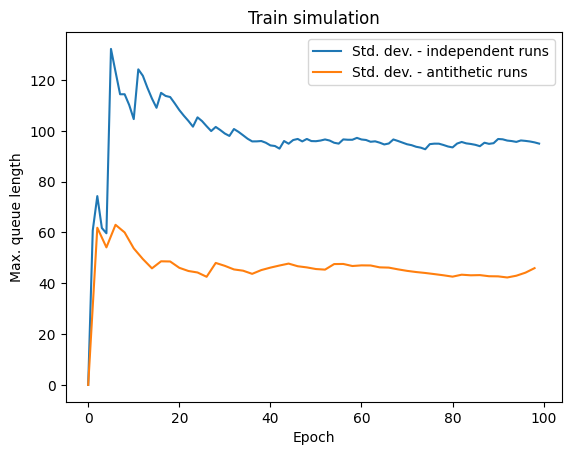

In [24]:
fig = plt.figure()
ax = plt.subplot(1, 1, 1)

ax.plot(sd_independent, label="Std. dev. - independent runs")
ax.plot(
    np.arange(0, sd_independent.shape[0], 2),
    sd_antithetic,
    label="Std. dev. - antithetic runs",
)
ax.set(title="Train simulation", xlabel="Epoch", ylabel="Max. queue length")
ax.legend()
fig.savefig("figure_antithetic.pdf", dpi=300)
plt.show()

It works